In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

ds = load_dataset("behavior-in-the-wild/LAMBDA")
ds


C:\Users\Thao\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 1964
    })
    test: Dataset({
        features: ['video_id', 'recall_score', 'youtube_id', 'ad_details'],
        num_rows: 219
    })
})

In [2]:
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

df = pd.concat([df_train, df_test], ignore_index=True)

df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   video_id      2183 non-null   int64  
 1   recall_score  2183 non-null   float64
 2   youtube_id    2183 non-null   str    
 3   ad_details    2183 non-null   object 
dtypes: float64(1), int64(1), object(1), str(1)
memory usage: 91.7+ KB


,video_id,recall_score,youtube_id,ad_details
0,1437,0.33,fjE8uCbWEhQ,"{'Audio': '', 'Brand': 'Mondelez International..."
1,37,0.80,3DK8I80Yhgs,"{'Audio': 'Two full meals, $5.99 each. Marparo..."
2,1806,0.86,epvlMnOO3Ew,"{'Audio': 'Zsem tolik preponenta sebohhooztih,..."
3,1055,0.57,2ZsxgpRMBDg,{'Audio': 'Who doesn't dream about having smoo...
4,1839,0.33,QVfj-EYnZ6s,"{'Audio': '', 'Brand': 'Albertsons', 'Duration..."


In [3]:
df.shape

(2183, 4)

In [4]:
ad_details_df = pd.DataFrame(df["ad_details"].tolist()) 
df_new = pd.concat([df.drop(columns=["ad_details"]), ad_details_df], axis=1)
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Scenes,Title
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,"[{'Colors': 'Black,Black,Gray,Dark_Gray,Off_Wh...",India - Bournvita - Basketball TV Commercial
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,"[{'Colors': 'Dark_Brown,Red,Mustard,Gold,Beige...",Burger King Full Meals :15 TV Commercial
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,"[{'Colors': 'White,White', 'Description': 'sho...",Can print embellishment really attract new cli...
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,"[{'Colors': 'White,White,Dark_Gray', 'Descript...",Smooth Sexy Hair | Ulta Beauty
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,"[{'Colors': 'Khaki,Brown,Off_White,Gray,Silver...",Dry-Brined Turkey Breast | Simple Weeknight Di...


In [5]:
df_new.loc[0,"Scenes"]

array([{'Colors': 'Black,Black,Gray,Dark_Gray,Off_White', 'Description': 'shows a man with his eyes shut on a dark background', 'Emotions': 'achievement, incentive', 'Number': '1', 'Photography Style': 'minimalist', 'Tags': 'dark, text', 'Text Shown': 'Bournvita', 'Tone': 'neutral', 'Visual Complexity': 'Low'},
       {'Colors': 'Black,Dark_Brown,Mud_Green,Dark_Brown,Mud_Green,Dark_Green,Gray,Brown', 'Description': 'shows an animated basketball video with an image of a person dunking a basketball through the hoop', 'Emotions': 'compete, enjoy, recreational', 'Number': '2', 'Photography Style': 'sports', 'Tags': 'ball, basket, basketball, basketball court, basketball game, basketball hoop, boy, child, dunk, floor, gym, net, play, rim', 'Text Shown': '', 'Tone': 'neutral', 'Visual Complexity': ''},
       {'Colors': 'Black,Dark_Gray,Mud_Green,Dark_Brown,Dark_Brown,Black,Dark_Gray,Gray', 'Description': 'shows a young girl in a basketball uniform on a basketball court', 'Emotions': 'achiev

In [6]:
import pandas as pd
import ast

# Parse if stored as string
df_new['Scenes'] = df_new['Scenes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def aggregate_scenes(scenes):
    aggregated = {}
    for scene in scenes:
        for key, val in scene.items():
            if key == 'Number':
                continue
            col = f"scenes_{key.lower().replace(' ', '_')}"
            if col not in aggregated:
                aggregated[col] = set()
            # Split on comma in case the value itself is a list string
            if isinstance(val, str) and val.strip():
                for v in val.split(','):
                    aggregated[col].add(v.strip())
    # Convert sets back to comma-separated strings
    return pd.Series({k: ', '.join(sorted(v)) for k, v in aggregated.items()})

scenes_agg = df_new['Scenes'].apply(aggregate_scenes)
df_new = pd.concat([df_new.drop(columns=['Scenes']), scenes_agg], axis=1)

In [7]:
df_new.head()

,video_id,recall_score,youtube_id,Audio,Brand,Duration,Orientation,Pace,Title,scenes_colors,scenes_description,scenes_emotions,scenes_photography_style,scenes_tags,scenes_text_shown,scenes_tone,scenes_visual_complexity
0,1437,0.33,fjE8uCbWEhQ,,Mondelez International,54 second,landscape,low,India - Bournvita - Basketball TV Commercial,"Black, Brown, Dark_Brown, Dark_Gray, Dark_Gree...",shows a basketball court and a man standing in...,"abuse, achievement, anger, cheering, compete, ...","minimalist, sports","appear, arena, arm, athletic, balance, ball, b...","""What are you waiting for? Let's go, 'only onc...",neutral,"High, Low"
1,37,0.80,3DK8I80Yhgs,"Two full meals, $5.99 each. Marparoya, crispy ...",Burger King,15 second,landscape,medium,Burger King Full Meals :15 TV Commercial,"Beige, Black, Brown, Cream, Dark_Brown, Dark_R...",shows a close up of two drinks with a glass in...,", bitter, confidence, confident, delicious, di...","commercial, composite, food","advertisement, alcohol, art, beverage, bite, b...","'""BK'Royal Crispy""', '""BK'RoyalCrispy""', '99',...","neutral, warm","High, Low"
2,1806,0.86,epvlMnOO3Ew,"Zsem tolik preponenta sebohhooztih, kar povaja...",Xerox,33 second,landscape,low,Can print embellishment really attract new cli...,"Black, Cyan, Dark_Blue, Dark_Brown, Dark_Green...",shows a blue book on the ground with intricate...,"best, betrayal, compete, concentrated, confide...","business, editorial, minimalist, product","banknote, blanket, blue, book, bookshelf, box,...","'Kanovits Print', 'Owner', 'attract new client...","cool, neutral",Low
3,1055,0.57,2ZsxgpRMBDg,"Who doesn't dream about having smooth, silky, ...",Ulta Beauty,39 second,landscape,low,Smooth Sexy Hair | Ulta Beauty,"Black, Brown, Dark_Blue, Dark_Brown, Dark_Gray...",'a person getting their hair washed by a woman...,", bad, care, comfort, comfortable, disgust, di...","commercial, composite, portrait, product","ball, barber, battery, beautiful, beauty salon...",", '&', '&SEAL', 'BEAUTY', 'COCONUT', 'COCONUTO...",neutral,"High, Low"
4,1839,0.33,QVfj-EYnZ6s,,Albertsons,52 second,square,low,Dry-Brined Turkey Breast | Simple Weeknight Di...,"Black, Brown, Dark_Brown, Dark_Red, Gray, Khak...",'a person preparing food on a plate in a glass...,", bad, decay, good, protective, tasty","commercial, product","add, bowl, butter, chicken, chicken breast, cu...","'Albertsons', 'OF BREAST', 1/2 TBSP SUGAR', Al...",neutral,Low


In [8]:
df_new["duration_seconds"] = df_new["Duration"].str.extract(r"(\d+)").astype(float)

In [9]:
print(df_new["Pace"].value_counts(dropna=False))

Pace
low       1373
medium     716
high        94
Name: count, dtype: int64


In [10]:
print(df_new["Orientation"].value_counts(dropna=False))

Orientation
landscape    2105
portrait       43
square         35
Name: count, dtype: int64


In [11]:
print(df_new["Brand"].value_counts(dropna=False))

Brand
Netflix                      121
Walt-Disney                   89
Ulta Beauty                   78
Viacom                        69
Adobe                         63
                            ... 
Henryschein                    1
L'Oreal Paris                  1
Quest Diagnostics              1
Williams                       1
American Family Insurance      1
Name: count, Length: 263, dtype: int64


In [12]:
print(df_new["scenes_colors"].value_counts(dropna=False))

scenes_colors
                                                                                                                                                                120
Black, Dark_Gray, Gray, Off_White, Silver, White                                                                                                                  6
Black, Dark_Gray, Gray                                                                                                                                            4
Black, Dark_Brown, Dark_Gray, Dark_Pink, Gray, Off_White                                                                                                          3
Black, Brown, Dark_Brown, Dark_Gray, Gray, Khaki, Mud_Green, Olive, Orange                                                                                        3
                                                                                                                                                               ... 
Bl

In [13]:
from collections import Counter

color_counts = Counter() 

df_new["scenes_colors"].dropna().apply(
    lambda x: color_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(color_counts).sort_values(ascending=False)

Black           1902
Dark_Brown      1799
Gray            1776
Dark_Gray       1644
White           1555
Brown           1404
Dark_Blue       1280
Mud_Green       1181
Off_White       1154
Olive           1128
Orange          1005
Dark_Pink        956
Light_Blue       948
Khaki            936
Dark_Green       878
Silver           867
Royal_Blue       830
Dark_Red         771
Cyan             737
Pink             730
Red              726
Emerald          691
Lavender         559
Cream            533
Maroon           499
Purple           411
Tan              401
Light_Green      265
Blue             262
Mustard          260
Yellow           196
Turquoise        192
Beige            190
Lilac            179
Green            178
Plum             172
Magenta          107
Gold             106
Violet            88
Bright_Green      85
dtype: int64

In [14]:
top_colors = [color for color, count in color_counts.most_common(15)]

top_colors

['Black',
 'Dark_Brown',
 'Gray',
 'Dark_Gray',
 'White',
 'Brown',
 'Dark_Blue',
 'Mud_Green',
 'Off_White',
 'Olive',
 'Orange',
 'Dark_Pink',
 'Light_Blue',
 'Khaki',
 'Dark_Green']

In [15]:
df_color = df_new[["video_id", "recall_score"]].copy()
df_color.head()

,video_id,recall_score
0,1437,0.33
1,37,0.80
2,1806,0.86
3,1055,0.57
4,1839,0.33


In [16]:
for color in top_colors:
    df_color[f"color_{color}"] = df_new["scenes_colors"].fillna("").apply(
        lambda x: int(color in [c.strip() for c in x.split(",")])
    )

df_color.head()

,video_id,recall_score,color_Black,color_Dark_Brown,color_Gray,color_Dark_Gray,color_White,color_Brown,color_Dark_Blue,color_Mud_Green,color_Off_White,color_Olive,color_Orange,color_Dark_Pink,color_Light_Blue,color_Khaki,color_Dark_Green
0,1437,0.33,1,1,1,1,0,1,0,1,1,0,0,0,0,0,1
1,37,0.80,1,1,0,0,0,1,0,1,0,1,1,0,0,1,0
2,1806,0.86,1,1,1,0,1,0,1,1,1,1,0,1,1,1,1
3,1055,0.57,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0
4,1839,0.33,1,1,1,0,0,1,0,0,1,1,1,0,0,1,0


               Color  Correlation  p-value
0        color_Black       0.0650   0.0024
14  color_Dark_Green       0.0563   0.0086
6    color_Dark_Blue       0.0557   0.0092
1   color_Dark_Brown       0.0479   0.0251
3    color_Dark_Gray       0.0446   0.0373
7    color_Mud_Green       0.0403   0.0596
5        color_Brown       0.0144   0.5017
10      color_Orange       0.0033   0.8778
12  color_Light_Blue      -0.0017   0.9368
13       color_Khaki      -0.0059   0.7826
11   color_Dark_Pink      -0.0084   0.6950
2         color_Gray      -0.0251   0.2409
8    color_Off_White      -0.0577   0.0070
9        color_Olive      -0.0643   0.0026
4        color_White      -0.0661   0.0020


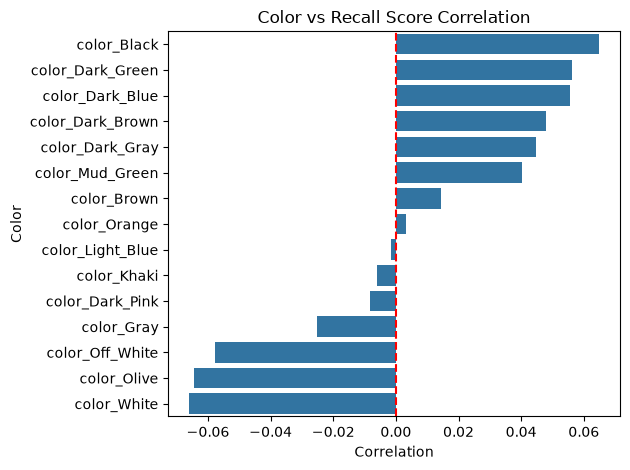

In [18]:
import seaborn as sns
from scipy.stats import pointbiserialr #Pearson Corr

color_cols = [c for c in df_color.columns if c.startswith("color_")]

results = []
for col in color_cols:
    corr, p_value = pointbiserialr(df_color[col], df_color["recall_score"].fillna(0))
    results.append({"Color": col, "Correlation": round(corr, 4), "p-value": round(p_value, 4)})

results_df = pd.DataFrame(results).sort_values("Correlation", ascending=False)
print(results_df)

# Visualize
sns.barplot(data=results_df, x="Correlation", y="Color")
plt.axvline(0, color="red", linestyle="--")
plt.title("Color vs Recall Score Correlation")
plt.tight_layout()
plt.show()

#Positive that color tends to appear in higher recall ads
#Negative lower recall
#p-value < 0.05 statistically significant


#all dark/deep colors show significant positive correlation
#Off_White, Olive, White: lighter/muted colors significantly associated with lower recall
#Brown, Orange, Khaki, Dark_Pink, Light_Blue, Gray: no meaningful relationship with recall

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Features = all color columns, target = recall_score
color_cols = [c for c in df_color.columns if c.startswith("color_")]

X = df_color[color_cols]
y = df_color["recall_score"].fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}") #Colors alone explain only 3.8% of recall score variance => not a strong predictor on its own
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# See which colors matter most
coef_df = pd.DataFrame({
    "Color": color_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)
print(coef_df) #ads with these dark/muted colors tend to have slightly higher recall, dark, high-contrast colors may be more visually memorable




R² Score:  0.0305
RMSE:      0.2745
               Color  Coefficient
0        color_Black     0.049232
7    color_Mud_Green     0.046932
6    color_Dark_Blue     0.028845
14  color_Dark_Green     0.023503
3    color_Dark_Gray     0.021963
1   color_Dark_Brown     0.019762
11   color_Dark_Pink     0.014312
13       color_Khaki     0.002417
10      color_Orange     0.002357
12  color_Light_Blue    -0.004214
5        color_Brown    -0.004350
8    color_Off_White    -0.015933
4        color_White    -0.039537
2         color_Gray    -0.042206
9        color_Olive    -0.067841


In [21]:
#scenes_emotions
print(df_new["scenes_emotions"].value_counts(dropna=False))
from collections import Counter

emotions_counts = Counter()  # ← reset every run

df_new["scenes_emotions"].dropna().apply(
    lambda x: emotions_counts.update([c.strip() for c in x.split(",") if c.strip()])
)

pd.Series(emotions_counts).sort_values(ascending=False)

scenes_emotions
abuse, achievement, anger, cheering, compete, confidence, determination, encouragement, enjoy, fancy, fun, happy, incentive, inspiration, motivation, motivational, rage, recreational, stress, success    1
, bitter, confidence, confident, delicious, dish, fancy, funky, gift, junk, positive, tasty, toast                                                                                                         1
best, betrayal, compete, concentrated, confident, excellent, gift, happiness, happy, magnificent, romance, romantic, smile, success, successful, vibrant, weird, wish                                      1
, bad, care, comfort, comfortable, disgust, disgusting, erotic, fetish, happy, laugh, love, perfect, positive, relaxation, romance, scream, smile, smiling, touching, unpleasant                           1
, bad, decay, good, protective, tasty                                                                                                                               

gift                       744
happy                      725
good                       638
emergency                  519
casual                     456
                          ... 
etiquette                    1
longing                      1
enjoying a good holiday      1
sex                          1
crave                        1
Length: 1159, dtype: int64

In [22]:
top_emotions = [emotion for emotion, count in emotions_counts.most_common(15)]

top_emotions

['gift',
 'happy',
 'good',
 'emergency',
 'casual',
 'danger',
 'holiday',
 'smiling',
 'togetherness',
 'fancy',
 'achievement',
 'fun',
 'smile',
 'bad',
 'celebration']

In [23]:
df_emotions = df_new[["video_id", "recall_score"]].copy()
for emotion in top_emotions:
    df_emotions[f"emotion_{emotion}"] = df_new["scenes_emotions"].fillna("").apply(
        lambda x: int(emotion in [c.strip() for c in x.split(",")])
    )

df_emotions.head()

,video_id,recall_score,emotion_gift,emotion_happy,emotion_good,emotion_emergency,emotion_casual,emotion_danger,emotion_holiday,emotion_smiling,emotion_togetherness,emotion_fancy,emotion_achievement,emotion_fun,emotion_smile,emotion_bad,emotion_celebration
0,1437,0.33,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0
1,37,0.80,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,1806,0.86,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0
3,1055,0.57,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0
4,1839,0.33,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


                 Emotion  Correlation  p-value
11           emotion_fun       0.1097   0.0000
6        emotion_holiday       0.0934   0.0000
1          emotion_happy       0.0749   0.0005
13           emotion_bad       0.0702   0.0010
9          emotion_fancy       0.0671   0.0017
5         emotion_danger       0.0662   0.0020
12         emotion_smile       0.0655   0.0022
14   emotion_celebration       0.0419   0.0505
4         emotion_casual       0.0350   0.1021
10   emotion_achievement       0.0234   0.2746
0           emotion_gift       0.0113   0.5974
8   emotion_togetherness       0.0061   0.7774
7        emotion_smiling       0.0004   0.9864
2           emotion_good      -0.0171   0.4248
3      emotion_emergency      -0.0815   0.0001


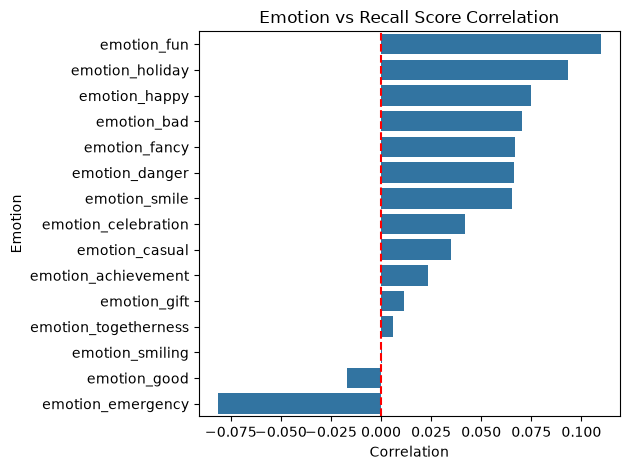

In [24]:
from scipy.stats import pointbiserialr #Pearson Corr

emotion_cols = [c for c in df_emotions.columns if c.startswith("emotion_")]

results = []
for col in emotion_cols:
    corr, p_value = pointbiserialr(df_emotions[col], df_emotions["recall_score"].fillna(0))
    results.append({"Emotion": col, "Correlation": round(corr, 4), "p-value": round(p_value, 4)})

results_df = pd.DataFrame(results).sort_values("Correlation", ascending=False)
print(results_df)

# Visualize
sns.barplot(data=results_df, x="Correlation", y="Emotion")
plt.axvline(0, color="red", linestyle="--")
plt.title("Emotion vs Recall Score Correlation")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Features = all color columns, target = recall_score
emotions_cols = [c for c in df_emotions.columns if c.startswith("emotion_")]

X = df_emotions[emotions_cols]
y = df_emotions["recall_score"].fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}") 
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# See which emotion matter most
coef_df_emotions = pd.DataFrame({
    "Emotion": emotions_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)
print(coef_df_emotions) #Emotions explain only 2.9% of recall variance weaker than colors (3.8%). Emotions alone are also not a strong predictor
#fun, fancy, danger, holiday, bad: surprisingly, intense or entertainment-driven emotions push recall up


R² Score:  0.0309
RMSE:      0.2744
                 Emotion  Coefficient
11           emotion_fun     0.064326
6        emotion_holiday     0.056367
5         emotion_danger     0.052114
13           emotion_bad     0.044198
9          emotion_fancy     0.040887
12         emotion_smile     0.036580
10   emotion_achievement     0.022210
1          emotion_happy     0.021869
4         emotion_casual     0.010564
14   emotion_celebration    -0.001989
0           emotion_gift    -0.005661
2           emotion_good    -0.006005
8   emotion_togetherness    -0.010588
7        emotion_smiling    -0.033589
3      emotion_emergency    -0.034530


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Set Low as the reference category
pace = pd.Categorical(
    df_new["Pace"],
    categories=["Low", "Medium", "High"]
)

# One-hot encoding
pace_dummies = pd.get_dummies(
    pace,
    prefix="Pace",
    drop_first=True,
    dtype=int
)

pace_dummies.index = df_new.index

# Combine Pace variables with recall_score
df_model_pace = pd.concat(
    [df_new["recall_score"], pace_dummies],
    axis=1
).dropna()

X_pace = df_model_pace.drop(columns=["recall_score"])
y_pace = df_model_pace["recall_score"]

# Train-test split
X_train_pace, X_test_pace, y_train_pace, y_test_pace = train_test_split(
    X_pace,
    y_pace,
    test_size=0.2,
    random_state=42
)

# Linear Regression
model_pace = LinearRegression()
model_pace.fit(X_train_pace, y_train_pace)

y_pred_pace = model_pace.predict(X_test_pace)

print("Pace model")
print(f"R² Score: {r2_score(y_test_pace, y_pred_pace):.4f}")
print(
    f"RMSE: {np.sqrt(mean_squared_error(y_test_pace, y_pred_pace)):.4f}"
)

pace_coef = pd.DataFrame({
    "Feature": X_pace.columns,
    "Coefficient": model_pace.coef_
})

print("\nReference category: Pace_Low")
print(pace_coef)

Pace model
R² Score: -0.0010
RMSE: 0.2789

Reference category: Pace_Low
       Feature  Coefficient
0  Pace_Medium          0.0
1    Pace_High          0.0


C:\Users\Thao\AppData\Local\Temp\ipykernel_12788\390976601.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  pace = pd.Categorical(


In [33]:
# Set Landscape as the reference category
orientation = pd.Categorical(
    df_new["Orientation"],
    categories=["Landscape", "Portrait", "Square"]
)

# One-hot encoding
orientation_dummies = pd.get_dummies(
    orientation,
    prefix="Orientation",
    drop_first=True,
    dtype=int
)

orientation_dummies.index = df_new.index

# Combine Orientation variables with recall_score
df_model_orientation = pd.concat(
    [df_new["recall_score"], orientation_dummies],
    axis=1
).dropna()

X_orientation = df_model_orientation.drop(columns=["recall_score"])
y_orientation = df_model_orientation["recall_score"]

# Train-test split
(
    X_train_orientation,
    X_test_orientation,
    y_train_orientation,
    y_test_orientation
) = train_test_split(
    X_orientation,
    y_orientation,
    test_size=0.2,
    random_state=42
)

# Linear Regression
model_orientation = LinearRegression()
model_orientation.fit(X_train_orientation, y_train_orientation)

y_pred_orientation = model_orientation.predict(X_test_orientation)

print("Orientation model")
print(
    f"R² Score: "
    f"{r2_score(y_test_orientation, y_pred_orientation):.4f}"
)
print(
    f"RMSE: "
    f"{np.sqrt(mean_squared_error(y_test_orientation, y_pred_orientation)):.4f}"
)

orientation_coef = pd.DataFrame({
    "Feature": X_orientation.columns,
    "Coefficient": model_orientation.coef_
})

print("\nReference category: Orientation_Landscape")
print(orientation_coef)

Orientation model
R² Score: -0.0010
RMSE: 0.2789

Reference category: Orientation_Landscape
                Feature  Coefficient
0  Orientation_Portrait          0.0
1    Orientation_Square          0.0


C:\Users\Thao\AppData\Local\Temp\ipykernel_12788\2881584775.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  orientation = pd.Categorical(


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# Select Duration and Recall Score
df_model_duration = df_new[
    ["duration_seconds", "recall_score"]
].dropna()

X_duration = df_model_duration[["duration_seconds"]]
y_duration = df_model_duration["recall_score"]

# Train-test split
(
    X_train_duration,
    X_test_duration,
    y_train_duration,
    y_test_duration
) = train_test_split(
    X_duration,
    y_duration,
    test_size=0.2,
    random_state=42
)

# Linear Regression
model_duration = LinearRegression()

model_duration.fit(
    X_train_duration,
    y_train_duration
)

# Prediction
y_pred_duration = model_duration.predict(
    X_test_duration
)

# Performance
print("Duration model")
print(
    f"R² Score: "
    f"{r2_score(y_test_duration, y_pred_duration):.4f}"
)
print(
    f"RMSE: "
    f"{np.sqrt(mean_squared_error(y_test_duration, y_pred_duration)):.4f}"
)

# Model coefficients
duration_coef = pd.DataFrame({
    "Feature": ["Intercept", "duration_seconds"],
    "Coefficient": [
        model_duration.intercept_,
        model_duration.coef_[0]
    ]
})

print("\nCoefficients")
print(duration_coef)

Duration model
R² Score: -0.0016
RMSE: 0.2790

Coefficients
            Feature  Coefficient
0         Intercept     0.597780
1  duration_seconds     0.000465


In [31]:
#Linear R with Pace and Orientation

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# onehot encoding for Pace and Orientation
pace_dummies = pd.get_dummies(df_new["Pace"], prefix="Pace", drop_first=True)
orient_dummies = pd.get_dummies(df_new["Orientation"], prefix="Orientation", drop_first=True)

# Combine with recall_score
df_model = pd.concat([df_new["recall_score"], pace_dummies, orient_dummies], axis=1).dropna()

X = df_model.drop(columns=["recall_score"])
y = df_model["recall_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pace_orient = LinearRegression()
model_pace_orient.fit(X_train, y_train)

y_pred = model_pace_orient.predict(X_test)

print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_pace_orient.coef_
}).sort_values("Coefficient", ascending=False)
print(coef_df)

#R² = 0.005 means Pace and Orientation together explain only 0.5% of recall variance 

#Pace
#Pace_medium (+0.089)  medium pace ads recall 0.089 higher than the reference
#Pace_low (+0.024) low pace ads recall 0.024 higher than the reference
#So the dropped category (fast/high pace) has the lowest recall — slower ads are more memorable

#Orientation
#Orientation_portrait (-0.087) portrait ads recall 0.087 lower than landscape
#Orientation_square (-0.225) square ads recall 0.225 lower than landscape
#Landscape orientation has the highest recall by far

R² Score:  -0.0084
RMSE:      0.2799
                Feature  Coefficient
1           Pace_medium     0.055742
0              Pace_low    -0.012118
2  Orientation_portrait    -0.126189
3    Orientation_square    -0.220093
